# Domain H: Cell Morphology and Structure–Function Relationships

This notebook addresses two questions using cell-body morphological features from the zarr multimodal data:
- **H1:** Does cell-body morphology predict transcriptomic cell type?
- **H2:** Does soma morphology correlate with functional properties independently of cell type?

**Data:** Zarr multimodal stores containing morphology/mask_properties (n_voxels, size_pc1/2/3_um, angle_deg_xy, centroid positions) and transcriptomic labels.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace
from scipy.optimize import curve_fit
from scipy.stats import kruskal, mannwhitneyu, spearmanr, pearsonr
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA, NMF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from pathlib import Path    
from matplotlib import cm, colors
import warnings
import anndata as ad
warnings.filterwarnings('ignore')

from functions.data_loading import load_mouse_zarr, zarr_to_df
from functions.visualization import polar_bar_plot


from functions.constants import (
    SUBCLASS_ORDER, SUBCLASS_COLORS, SUBCLASS_SHORT,
    SUPERTYPE_ORDER, SUPERTYPE_COLORS, SUPERTYPE_SHORT,
    SUPERTYPE_TO_SUBCLASS, SUBCLASS_SUPERTYPES
)

sns.set_context('talk')
sns.set_style('whitegrid')


In [2]:
# ══════════════════════════════════════════════════════════════════════
# Load data from zarr DATA_DIR stores
# ══════════════════════════════════════════════════════════════════════
DATA_DIR = Path('/root/capsule/data')
SCRATCH_DIR = Path('/root/capsule/scratch')
FIG_DIR = SCRATCH_DIR / 'Analysis_figures/Domain_A_Transcriptomic_Function/01_cell-type-specific-tuning-properties'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MOUSE_IDS = ['_'.join(f.stem.split('_')[1:3]) for f in DATA_DIR.glob('multimodal*')]
MOUSE_IDS.sort()
SESSIONS = ['session_1', 'session_2', 'session_3']

session_type = ['drifting_gratings']
MOUSE_IDS

['h_755252',
 'h_767018',
 'h_767022',
 'h_782149',
 'h_788406',
 'h_790322',
 'x_778174',
 'x_786297',
 'x_797371']

In [3]:
mouse_file_map = {}
for mid in MOUSE_IDS:
    h5_matches = sorted(DATA_DIR.glob(f'multimodal_{mid}*/multimodal_avg_{mid}.h5ad'))
    zarr_matches = sorted(DATA_DIR.glob(f'multimodal_{mid}*/multimodal_{mid}.zarr'))
    mouse_file_map[mid] = {
        'h5ad': h5_matches[0] if len(h5_matches) else None,
        'zarr': zarr_matches[0] if len(zarr_matches) else None,
    }

pd.DataFrame(mouse_file_map).T

,h5ad,zarr
h_755252,/root/capsule/data/multimodal_h_755252_2026-04...,/root/capsule/data/multimodal_h_755252_2026-04...
h_767018,/root/capsule/data/multimodal_h_767018_2026-04...,/root/capsule/data/multimodal_h_767018_2026-04...
h_767022,/root/capsule/data/multimodal_h_767022_2026-04...,/root/capsule/data/multimodal_h_767022_2026-04...
h_782149,/root/capsule/data/multimodal_h_782149_2026-04...,/root/capsule/data/multimodal_h_782149_2026-04...
h_788406,/root/capsule/data/multimodal_h_788406_2026-04...,/root/capsule/data/multimodal_h_788406_2026-04...
h_790322,/root/capsule/data/multimodal_h_790322_2026-04...,/root/capsule/data/multimodal_h_790322_2026-04...
x_778174,/root/capsule/data/multimodal_x_778174_2026-04...,/root/capsule/data/multimodal_x_778174_2026-04...
x_786297,/root/capsule/data/multimodal_x_786297_2026-04...,/root/capsule/data/multimodal_x_786297_2026-04...
x_797371,/root/capsule/data/multimodal_x_797371_2026-04...,/root/capsule/data/multimodal_x_797371_2026-04...


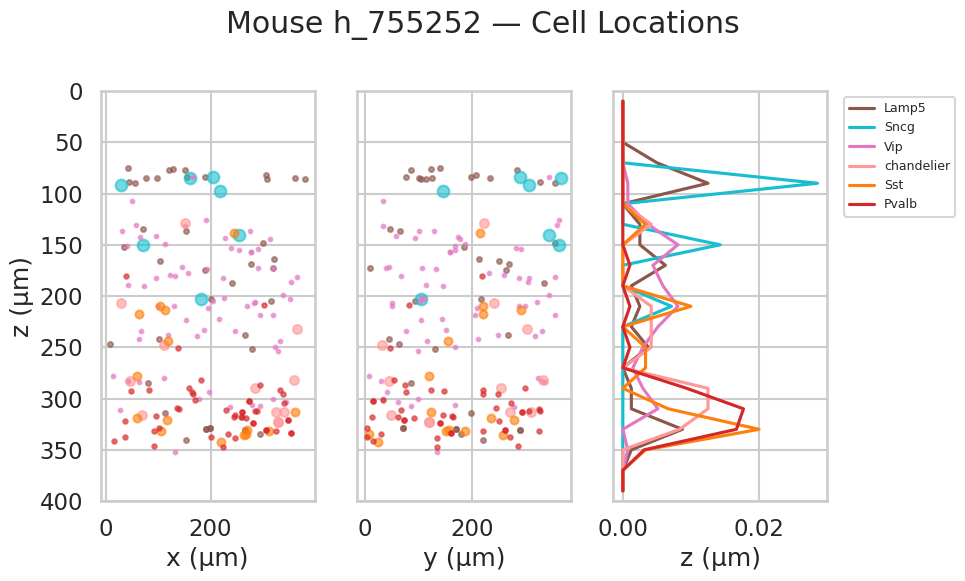

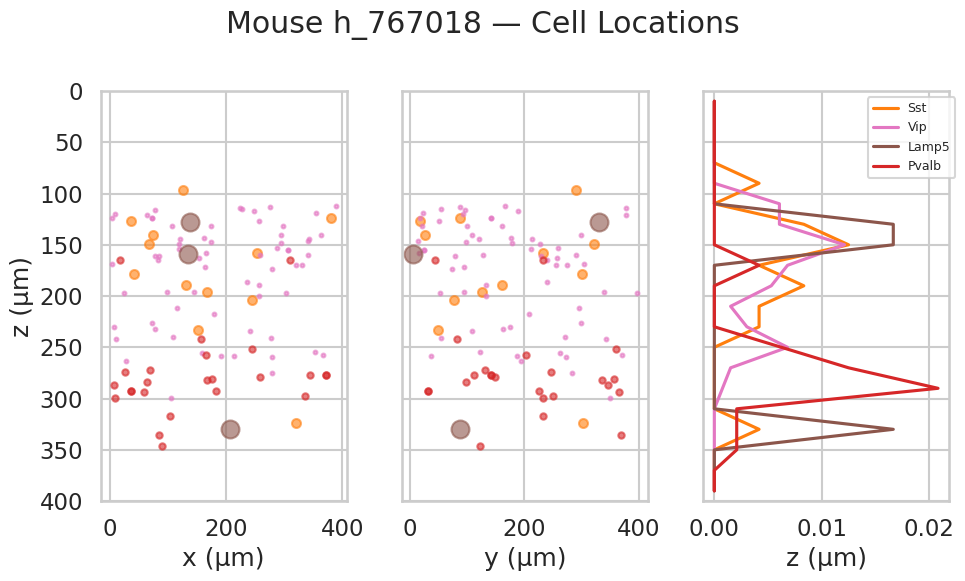

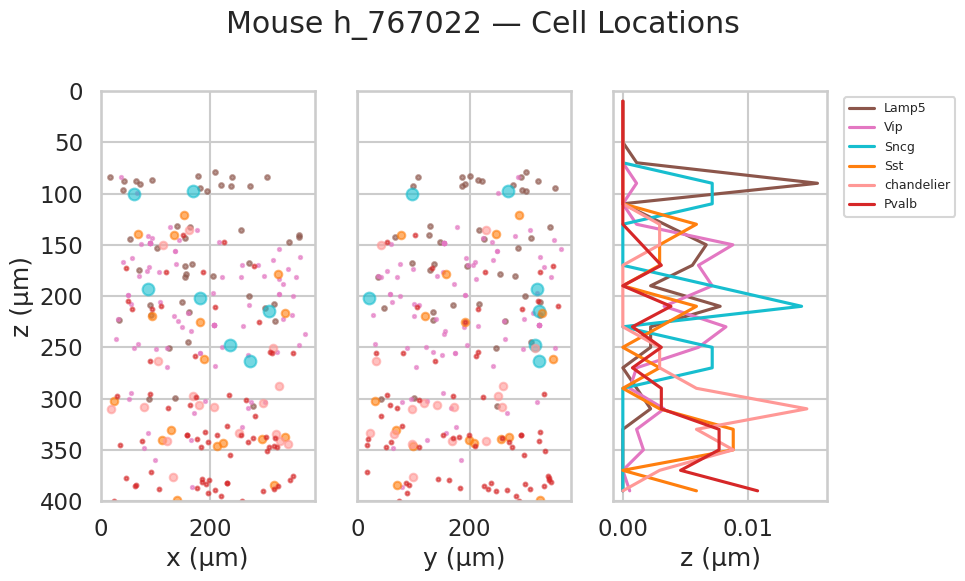

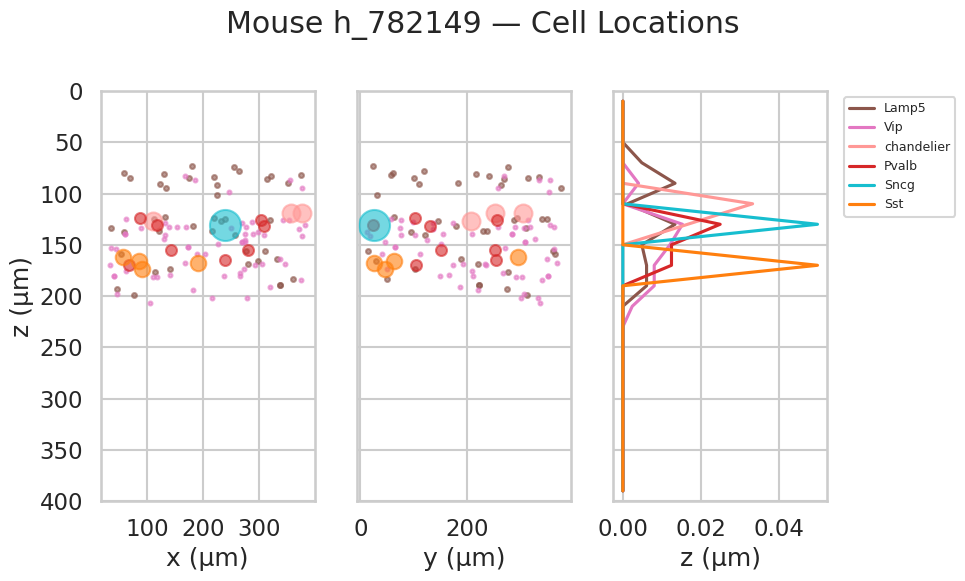

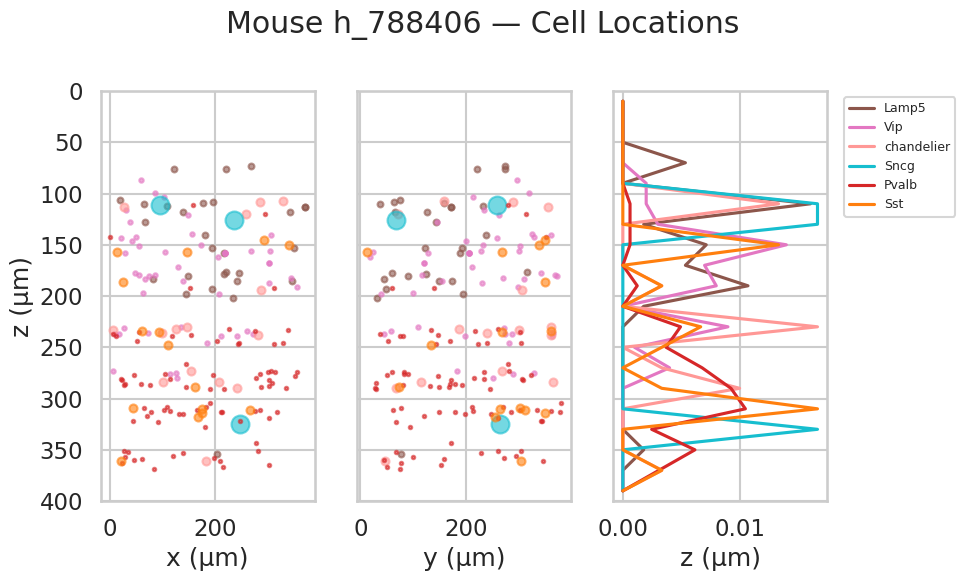

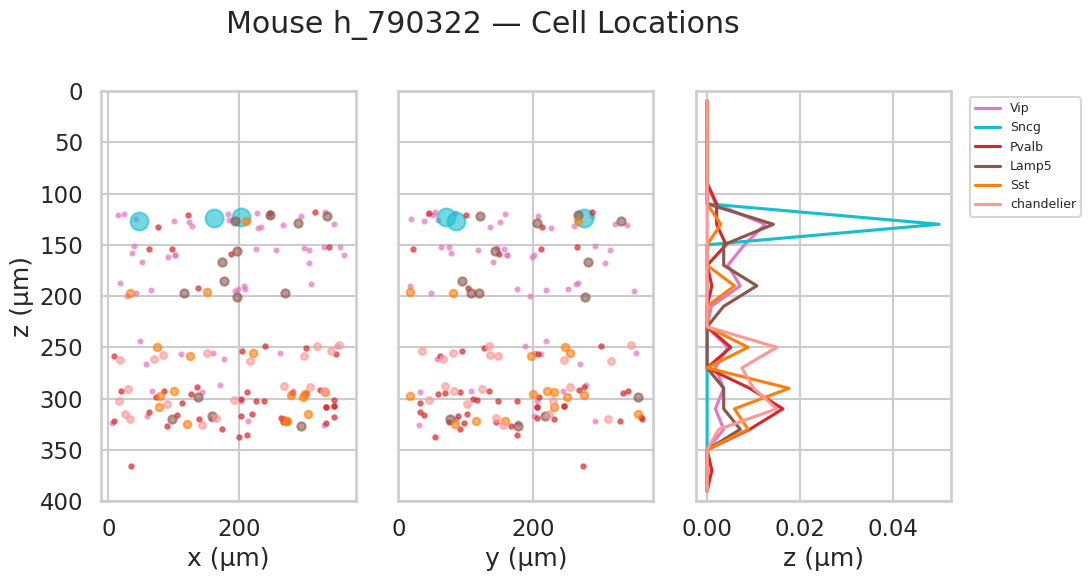

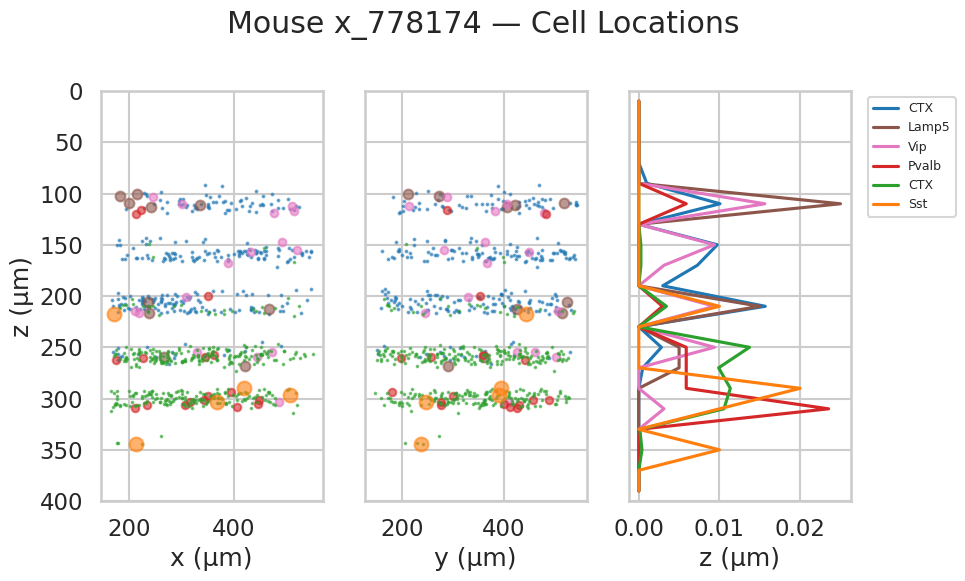

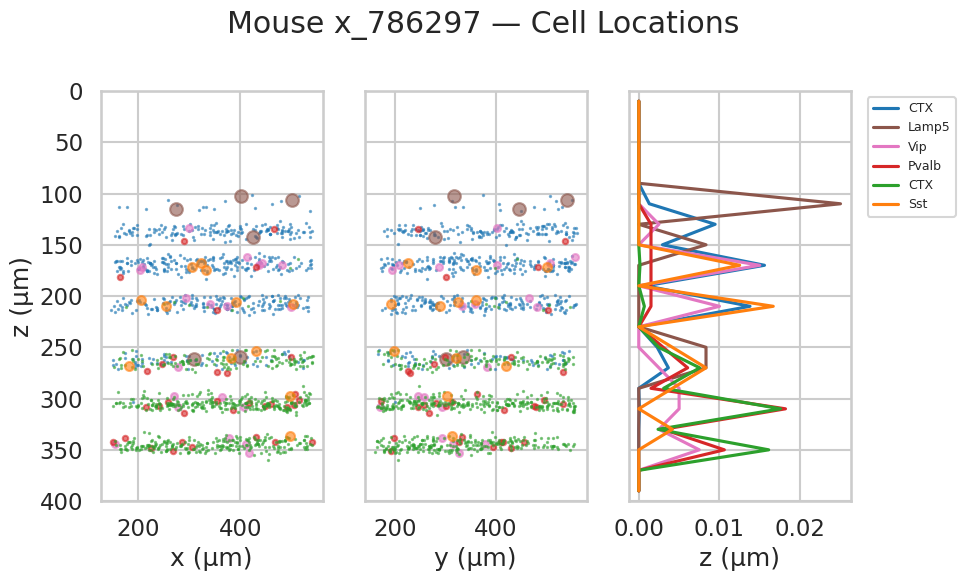

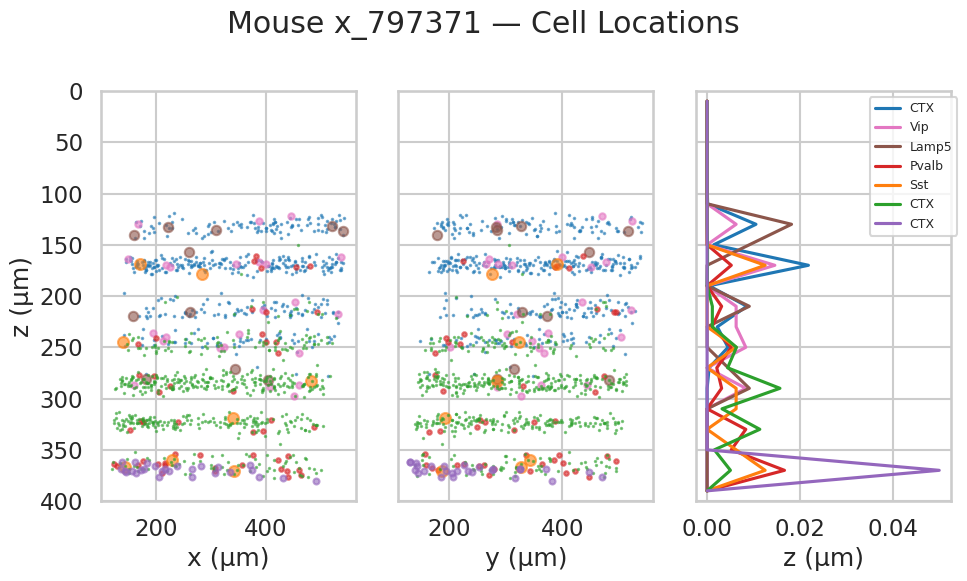

In [4]:
merged_cells_dict = {}
for mid in MOUSE_IDS:
    z = zarr.open(mouse_file_map[mid]['zarr'])
    unique_ids = z['unique_id'][:].astype(str)
    cxg = z['transcriptomics/cellxgene']
    cxg_df = zarr_to_df(cxg)
    ct = z['transcriptomics/cell_type']
    ct_df = zarr_to_df(ct)
    morph = z['morphology/mask_properties']
    morph_df = zarr_to_df(morph)

    merged_cells_df = pd.concat([cxg_df, ct_df, morph_df], axis=1)
    merged_cells_df['cell_id'] = unique_ids
    merged_cells_df.set_index('cell_id', inplace=True)
    merged_cells_dict[mid] = merged_cells_df

    fig, axs = plt.subplots(1, 3, figsize=(10, 6))

    for sc in merged_cells_df['subclass_name'].unique():
            mask = merged_cells_df['subclass_name'] == sc
            ax = axs[0]
            ax.scatter(merged_cells_df.loc[mask, 'centroid_x_um'], merged_cells_df.loc[mask, 'centroid_z_um'],
                    s=500/np.sum(mask), alpha=0.6, label=sc.split()[-2], color = SUBCLASS_COLORS[sc])
            ax.set_xlabel('x (µm)'); ax.set_ylabel('z (µm)')
            ax.set_ylim(400, 0)

            ax = axs[1]
            ax.scatter(merged_cells_df.loc[mask, 'centroid_y_um'], merged_cells_df.loc[mask, 'centroid_z_um'],
                    s=500/np.sum(mask), alpha=0.6, label=' '.join(sc.split()[1:-1]), color = SUBCLASS_COLORS[sc])
            ax.set_xlabel('y (µm)')
            ax.set_yticklabels([])
            # ax.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
            ax.set_ylim(400, 0)

            ax = axs[2]
            N, z = np.histogram(merged_cells_df.loc[mask, 'centroid_z_um'], bins=20, range=(0, 400), density=True)
            ax.plot(N,z[:-1] + 10, label=sc.split()[-2], color=SUBCLASS_COLORS[sc])
            ax.set_xlabel('z (µm)')
            ax.set_yticklabels([])
            ax.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
            ax.set_ylim(400, 0)
    plt.suptitle(f'Mouse {mid} — Cell Locations')
    plt.tight_layout()
    plt.show()

In [ ]:

# ── Load morphology data from all mice ──
morph_records = []
for mouse_id in MOUSE_IDS:
    z = zarr.open(f'{ZARR_DIR}/{mouse_id}_multimodal_data.zarr', 'r')
    morph = z['morphology/mask_properties']
    subclass_names = z['transcriptomics/cell_type/subclass_name'][:]
    supertype_names = z['transcriptomics/cell_type/supertype_name'][:]
    n_cells = len(subclass_names)
    
    n_voxels = morph['n_voxels'][:]
    size_pc1 = morph['size_pc1_um'][:]
    size_pc2 = morph['size_pc2_um'][:]
    size_pc3 = morph['size_pc3_um'][:]
    angle = morph['angle_deg_xy'][:]
    cx = morph['centroid_x_um'][:]
    cy = morph['centroid_y_um'][:]
    cz = morph['centroid_z_um'][:]
    
    for i in range(n_cells):
        morph_records.append({
            'mouse_id': mouse_id,
            'subclass': subclass_names[i],
            'supertype': supertype_names[i],
            'n_voxels': n_voxels[i],
            'size_pc1_um': size_pc1[i],
            'size_pc2_um': size_pc2[i],
            'size_pc3_um': size_pc3[i],
            'angle_deg_xy': angle[i],
            'centroid_z_um': cz[i],
            'elongation': size_pc1[i] / max(size_pc2[i], 0.1),
            'flatness': size_pc2[i] / max(size_pc3[i], 0.1),
        })

morph_df = pd.DataFrame(morph_records)
morph_df['subclass_short'] = morph_df['subclass'].map(SUBCLASS_SHORT)
present_subclasses = [s for s in SUBCLASS_ORDER if s in morph_df['subclass'].unique()]

print(f"Total cells with morphology: {len(morph_df)}")
print(f"\nMorphology summary:")
print(morph_df[['n_voxels', 'size_pc1_um', 'elongation', 'flatness']].describe().round(2))

## H1: Cell-Body Morphology Predicts Transcriptomic Cell Type

Compare morphological features across subclasses and train a classifier to predict subclass from morphology alone.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# H1  Morphological Feature Comparison Across Cell Types
# ══════════════════════════════════════════════════════════════════════

short_order = [SUBCLASS_SHORT[s] for s in present_subclasses]
short_pal = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

features = ['n_voxels', 'size_pc1_um', 'elongation', 'flatness', 'angle_deg_xy', 'centroid_z_um']
titles = ['Cell Body Volume (voxels)', 'Soma Size PC1 (µm)', 'Elongation (PC1/PC2)',
          'Flatness (PC2/PC3)', 'Soma Orientation Angle (°)', 'Cortical Depth (µm)']

for idx, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[idx // 3, idx % 3]
    sns.violinplot(data=morph_df[morph_df['subclass_short'].isin(short_order)],
                   x='subclass_short', y=feat, order=short_order,
                   palette=short_pal, cut=0, inner='box', ax=ax)
    ax.set_title(f'H1: {title}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    
    # Kruskal-Wallis test
    groups = [morph_df.loc[morph_df['subclass'] == s, feat].dropna().values
              for s in present_subclasses if (morph_df['subclass'] == s).sum() >= 3]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        ax.text(0.02, 0.98, f'H={stat:.1f}, p={p:.1e}', transform=ax.transAxes,
                fontsize=8, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# H1.2  Morphology-Based Cell-Type Classification
# ══════════════════════════════════════════════════════════════════════

# Prepare features
feature_cols = ['n_voxels', 'size_pc1_um', 'size_pc2_um', 'size_pc3_um',
                'elongation', 'flatness', 'angle_deg_xy', 'centroid_z_um']

valid = morph_df[feature_cols + ['subclass_short', 'mouse_id']].dropna()
X = valid[feature_cols].values
y = valid['subclass_short'].values
groups = valid['mouse_id'].values

# Leave-one-mouse-out cross-validation
logo = LeaveOneGroupOut()
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
y_pred = cross_val_predict(clf, X, y, groups=groups, cv=logo)

# Confusion matrix
labels = short_order
cm = confusion_matrix(y, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
ax = axes[0]
sns.heatmap(cm_norm, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('H1: Morphology → Subclass (Leave-Mouse-Out)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

# Feature importance
clf.fit(X, y)
importances = clf.feature_importances_
ax = axes[1]
ax.barh(feature_cols, importances, color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('H1: Random Forest Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, labels=labels, zero_division=0))

# 2D scatter: elongation vs volume
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for sc in present_subclasses:
    mask = morph_df['subclass'] == sc
    ax.scatter(morph_df.loc[mask, 'n_voxels'], morph_df.loc[mask, 'elongation'],
               c=SUBCLASS_COLORS[sc], label=SUBCLASS_SHORT[sc], alpha=0.4, s=15)
ax.set_xlabel('Cell Body Volume (voxels)')
ax.set_ylabel('Elongation (PC1/PC2)')
ax.set_title('H1: Morphological Space by Cell Type', fontweight='bold')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()